In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv('data_files/world_cup_last_50_years.csv')

df['result'] = df.apply(lambda x:
    'Home win' if x['winner'] == x['home_team'] else
    ('Away win' if x['winner'] == x['away_team'] else 'Draw'), axis=1)

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(df['result'].value_counts())
df

Dataset: 832 rows, 10 columns
result
Home win    303
Away win    271
Draw        258
Name: count, dtype: int64


,year,date,stage,home_team,away_team,home_goals,away_goals,winner,match_id,result
0,1974,1974-06-10,Quarter-finals,South Korea,Sweden,0,0,Draw,1,Draw
1,1974,1974-06-10,Quarter-finals,Ghana,Switzerland,2,0,Ghana,2,Home win
2,1974,1974-06-10,Group Stage,Sweden,Saudi Arabia,2,0,Sweden,3,Home win
3,1974,1974-06-10,Group Stage,Cameroon,Uruguay,2,1,Cameroon,4,Home win
4,1974,1974-06-10,Group Stage,Nigeria,Japan,2,1,Nigeria,5,Home win
...,...,...,...,...,...,...,...,...,...,...
827,2022,2022-11-26,Group Stage,Tunisia,Algeria,1,1,Draw,828,Draw
828,2022,2022-11-26,Group Stage,Croatia,Sweden,3,2,Croatia,829,Home win
829,2022,2022-11-26,Group Stage,Iran,Egypt,1,0,Iran,830,Home win
830,2022,2022-11-27,Group Stage,Egypt,Nigeria,2,0,Egypt,831,Home win


In [3]:
# Team win rates
team_wins  = df['winner'].value_counts()
team_games = pd.concat([df['home_team'], df['away_team']]).value_counts()
team_winrate = (team_wins / team_games).fillna(0)

df['home_winrate'] = df['home_team'].map(team_winrate)
df['away_winrate'] = df['away_team'].map(team_winrate)

# Goal difference
df['home_goal_diff'] = df['home_goals'] - df['away_goals']
avg_goal_diff = df.groupby('home_team')['home_goal_diff'].mean()
df['home_avg_goal_diff'] = df['home_team'].map(avg_goal_diff)
df['away_avg_goal_diff'] = df['away_team'].map(avg_goal_diff)

# Stage weight
stage_order = {'Group Stage': 1, 'Round of 16': 2,
               'Quarter-finals': 3, 'Semi-finals': 4,
               'Third place': 5, 'Final': 6}
df['stage_weight'] = df['stage'].map(stage_order).fillna(1)

# Year
df['year'] = pd.to_datetime(df['date']).dt.year

# Head to head
def h2h_winrate(row):
    past = df[(df['date'] < row['date']) &
              (((df['home_team'] == row['home_team']) & (df['away_team'] == row['away_team'])) |
               ((df['home_team'] == row['away_team']) & (df['away_team'] == row['home_team'])))]
    if len(past) == 0:
        return 0.5
    return (past['winner'] == row['home_team']).mean()

df['h2h_winrate'] = df.apply(h2h_winrate, axis=1)


# Encode teams
le_team = LabelEncoder()
le_team.fit(pd.concat([df['home_team'], df['away_team']]))
df['home_team_enc'] = le_team.transform(df['home_team'])
df['away_team_enc'] = le_team.transform(df['away_team'])

print("Features created successfully!")


Features created successfully!


In [4]:
features = ['home_team_enc', 'away_team_enc', 'stage_weight',
            'year', 'home_winrate', 'away_winrate',
            'home_avg_goal_diff', 'away_avg_goal_diff', 'h2h_winrate']

X = df[features]

le_result = LabelEncoder()
y = le_result.fit_transform(df['result'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_pred)*100:.1f}%")

Accuracy: 37.7%


In [5]:
def predict_match(home, away, year=2026, stage='Final'):
    home_enc = le_team.transform([home])[0]
    away_enc = le_team.transform([away])[0]
    home_wr  = team_winrate.get(home, 0.5)
    away_wr  = team_winrate.get(away, 0.5)
    home_gd  = avg_goal_diff.get(home, 0)
    away_gd  = avg_goal_diff.get(away, 0)
    h2h      = df[(df['home_team']==home) & 
                  (df['away_team']==away)]['h2h_winrate'].mean()
    h2h      = 0.5 if np.isnan(h2h) else h2h
    sw       = stage_order.get(stage, 1)

    row   = pd.DataFrame([[home_enc, away_enc, sw, year,
                           home_wr, away_wr, home_gd, away_gd, h2h]],
                          columns=features)
    pred  = rf.predict(row)[0]
    proba = rf.predict_proba(row)[0]
    outcome = le_result.inverse_transform([pred])[0]

    print(f"\n{home} vs {away} | {stage} {year}")
    print(f"Predicted: {outcome}")
    print(f"  Away win:  {proba[0]*100:.1f}%")
    print(f"  Draw:      {proba[1]*100:.1f}%")
    print(f"  Home win:  {proba[2]*100:.1f}%")

# Try it!
predict_match("Brazil", "Germany", stage="Final")
predict_match("France", "Argentina", stage="Semi-finals")


Brazil vs Germany | Final 2026
Predicted: Home win
  Away win:  36.0%
  Draw:      26.0%
  Home win:  38.0%

France vs Argentina | Semi-finals 2026
Predicted: Home win
  Away win:  25.0%
  Draw:      28.0%
  Home win:  47.0%


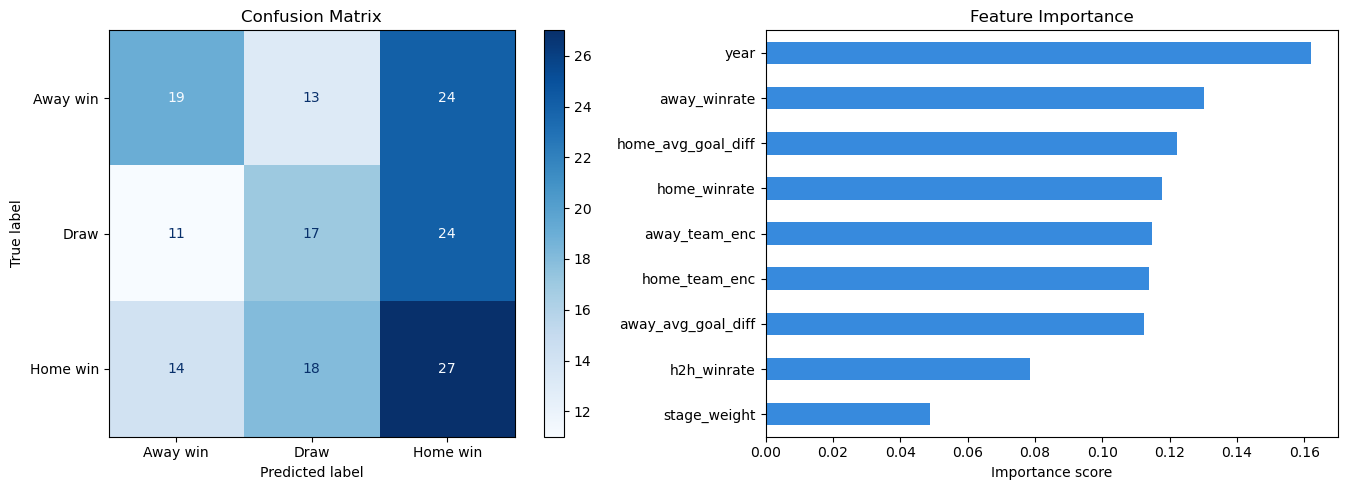

              precision    recall  f1-score   support

    Away win       0.43      0.34      0.38        56
        Draw       0.35      0.33      0.34        52
    Home win       0.36      0.46      0.40        59

    accuracy                           0.38       167
   macro avg       0.38      0.37      0.37       167
weighted avg       0.38      0.38      0.38       167



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=le_result.classes_).plot(
    cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Feature importance
pd.Series(rf.feature_importances_, index=features)\
  .sort_values()\
  .plot(kind='barh', color='#378ADD', ax=axes[1])
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

print(classification_report(y_test, rf_pred, target_names=le_result.classes_))